<a href="https://www.kaggle.com/code/sonawanelalitsunil/linkedin-data-jobs-ml?scriptVersionId=237500881" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/linkedin-data-jobs-dataset/clean_jobs.csv


## Title: 
LinkedIn Data Jobs Dataset

## Description: 
A curated dataset of data-related job listings from LinkedIn, including job titles, companies, locations, posting dates, and required skills — ideal for job market analysis and career trend insights.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/linkedin-data-jobs-dataset/clean_jobs.csv')

In [3]:
df.head()

,id,title,company,location,link,source,date_posted,work_type,employment_type,description
0,1,Data Analyst,Meta,"New York, NY",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
1,2,Data Analyst,Meta,"San Francisco, CA",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
2,3,Data Analyst,Meta,"Los Angeles, CA",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
3,4,Data Analyst,Meta,"Washington, DC",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-14,NaN,NaN,The Social Measurement team is a growing team ...
4,5,Data Analyst II,Pinterest,"Chicago, IL",https://www.linkedin.com/jobs/view/data-analys...,LinkedIn,2025-04-16,NaN,NaN,About Pinterest\n\nMillions of people around t...


In [4]:
df.tail()

,id,title,company,location,link,source,date_posted,work_type,employment_type,description
322,691,Data Engineer- Python Pyspark,Virtusa,"Chennai, Tamil Nadu, India",https://in.linkedin.com/jobs/view/data-enginee...,LinkedIn,2025-04-10,NaN,NaN,Senior Data Engineer\n\nPosition Summary\n\nTh...
323,692,Data Engineer with Pyspark,Cognizant,"Bangalore Urban, Karnataka, India",https://in.linkedin.com/jobs/view/data-enginee...,LinkedIn,2025-04-13,NaN,NaN,Job Title:- Data Engineer with Pyspark\n\nLoca...
324,693,Data Engineer,Mercedes-Benz Malaysia,"Puchong, Selangor, Malaysia",https://my.linkedin.com/jobs/view/data-enginee...,LinkedIn,2025-04-16,NaN,NaN,"About Us\n\n\n\n\nAt Mercedes-Benz, we don’t j..."
325,740,Data Engineer I,IntePros,"Seattle, WA",https://www.linkedin.com/jobs/view/data-engine...,LinkedIn,2025-04-15,NaN,NaN,Data Engineer I – Infrastructure & Automation ...
326,741,Data Engineer,Snap Inc.,"Bellevue, WA",https://www.linkedin.com/jobs/view/data-engine...,LinkedIn,2025-04-16,NaN,NaN,Snap Inc is a technology company. We believe t...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327 entries, 0 to 326
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               327 non-null    int64  
 1   title            327 non-null    object 
 2   company          327 non-null    object 
 3   location         327 non-null    object 
 4   link             327 non-null    object 
 5   source           327 non-null    object 
 6   date_posted      327 non-null    object 
 7   work_type        0 non-null      float64
 8   employment_type  0 non-null      float64
 9   description      327 non-null    object 
dtypes: float64(2), int64(1), object(7)
memory usage: 25.7+ KB


In [6]:
df.describe()

,id,work_type,employment_type
count,327.000000,0.0,0.0
mean,382.605505,NaN,NaN
std,224.546087,NaN,NaN
min,1.000000,NaN,NaN
25%,132.500000,NaN,NaN
50%,425.000000,NaN,NaN
75%,599.500000,NaN,NaN
max,741.000000,NaN,NaN


In [7]:
df.isnull().sum()

id                   0
title                0
company              0
location             0
link                 0
source               0
date_posted          0
work_type          327
employment_type    327
description          0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

id                   int64
title               object
company             object
location            object
link                object
source              object
date_posted         object
work_type          float64
employment_type    float64
description         object
dtype: object

In [10]:
df.shape

(327, 10)

In [11]:
df.columns

Index(['id', 'title', 'company', 'location', 'link', 'source', 'date_posted',
       'work_type', 'employment_type', 'description'],
      dtype='object')

## Data visualizations

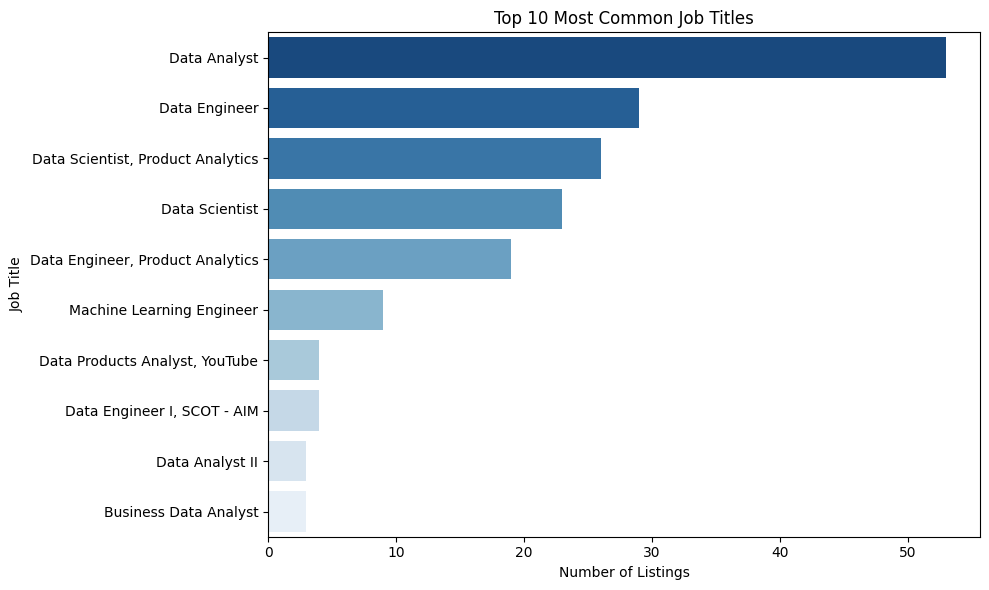

In [12]:
top_titles = df['title'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_titles.values, y=top_titles.index, palette='Blues_r')
plt.title('Top 10 Most Common Job Titles')
plt.xlabel('Number of Listings')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

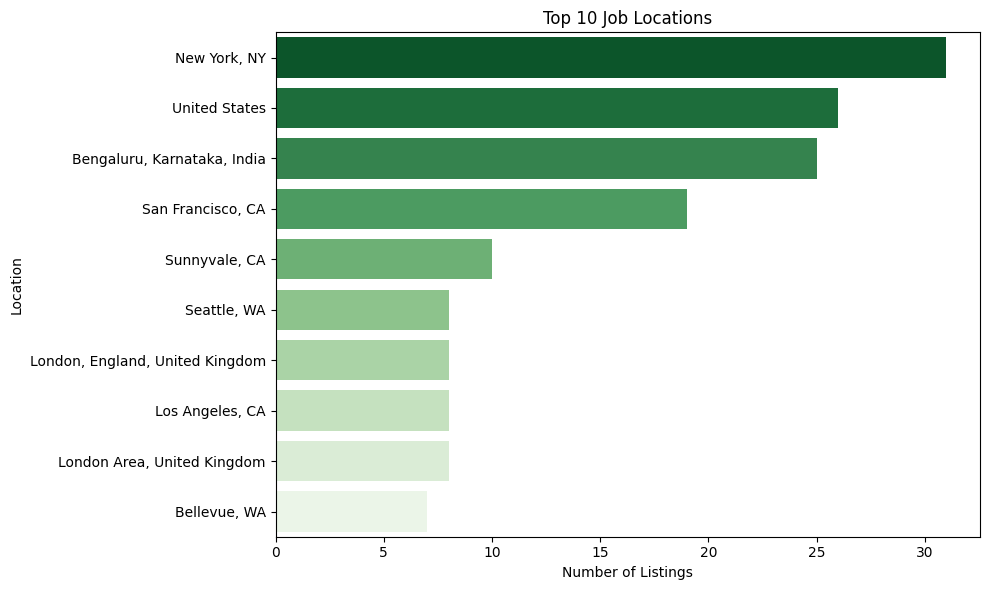

In [13]:
top_locations = df['location'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_locations.values, y=top_locations.index, palette='Greens_r')
plt.title('Top 10 Job Locations')
plt.xlabel('Number of Listings')
plt.ylabel('Location')
plt.tight_layout()
plt.show()


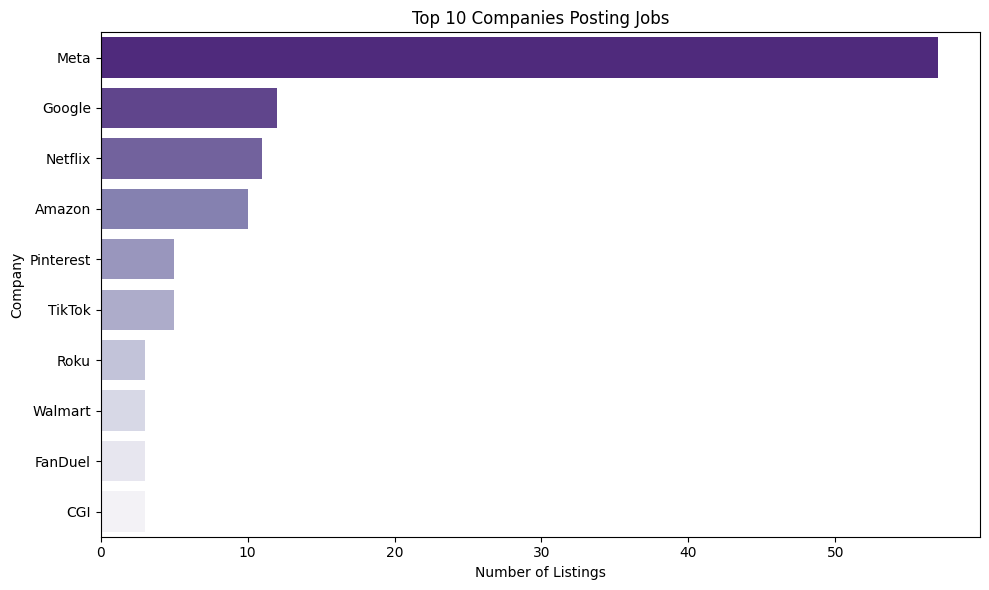

In [14]:
top_companies = df['company'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_companies.values, y=top_companies.index, palette='Purples_r')
plt.title('Top 10 Companies Posting Jobs')
plt.xlabel('Number of Listings')
plt.ylabel('Company')
plt.tight_layout()
plt.show()


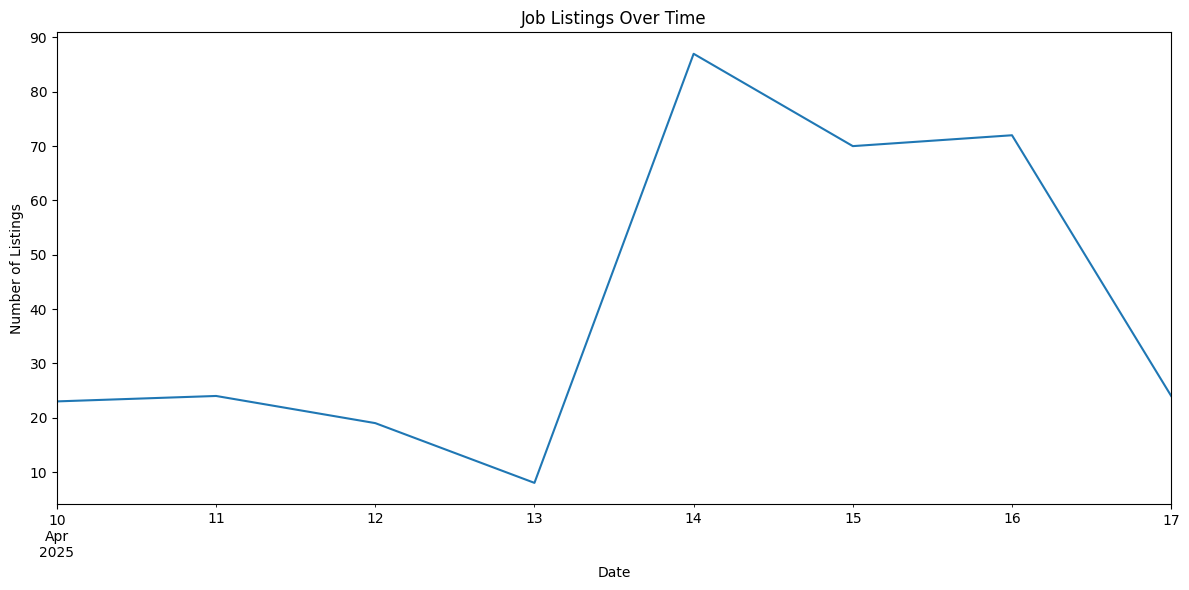

In [15]:
df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')
jobs_by_date = df['date_posted'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
jobs_by_date.plot()
plt.title('Job Listings Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()


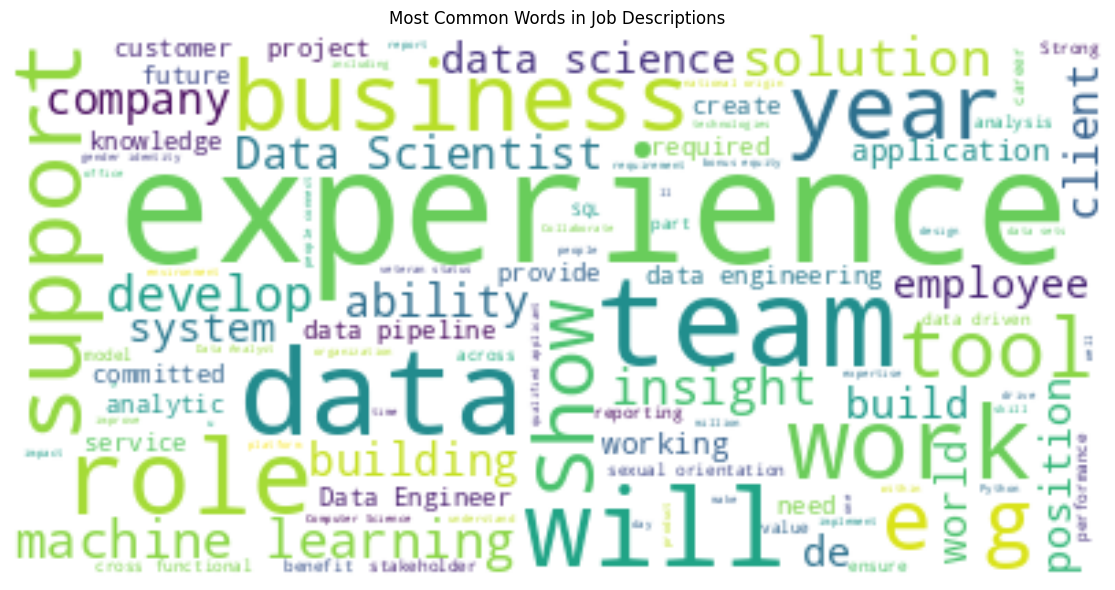

In [16]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

text = ' '.join(df['description'].dropna().tolist())
wordcloud = WordCloud(stopwords=STOPWORDS, background_color='white', max_words=100).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Job Descriptions')
plt.tight_layout()
plt.show()


## Predictve modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [18]:
# Step 2: Data Inspection - Check initial shape
print(f"Initial dataset shape: {df.shape}")

# Step 3: Handle missing values
df.dropna(inplace=True)

# After dropping missing values, check the shape again
print(f"Dataset shape after dropping missing values: {df.shape}")

# Step 4: Label Encoding for categorical variables
label_encoder = LabelEncoder()

# Encode 'work_type', 'employment_type', 'company', 'location' columns
df['work_type'] = label_encoder.fit_transform(df['work_type'])
df['employment_type'] = label_encoder.fit_transform(df['employment_type'])
df['company'] = label_encoder.fit_transform(df['company'])
df['location'] = label_encoder.fit_transform(df['location'])

# Step 5: Create the target column (Example: Binary classification based on the job title)
# Adjust this logic if necessary
df['target'] = df['title'].apply(lambda x: 1 if 'Engineer' in x else 0)

# Step 6: Check if the target column is balanced
print(f"Target column distribution:\n{df['target'].value_counts()}")

# Step 7: Select Features (X) and Target (y)
X = df[['work_type', 'employment_type', 'company', 'location']]  # Features
y = df['target']  # Target

# Step 8: Train-test Split
# Check the shapes of X and y to ensure they are not empty
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Ensure there are enough samples for training and testing
if X.shape[0] == 0 or y.shape[0] == 0:
    print("Error: Data is empty after preprocessing.")
else:
    # Perform train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")

    # Step 9: Apply Machine Learning Models

    # Logistic Regression
    log_reg = LogisticRegression(max_iter=1000)  # Adding max_iter for convergence if needed
    log_reg.fit(X_train, y_train)
    y_pred_log_reg = log_reg.predict(X_test)

    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)

    # Support Vector Machine (SVM)
    svm = SVC()
    svm.fit(X_train, y_train)
    y_pred_svm = svm.predict(X_test)

    # Step 10: Model Evaluation

    # Logistic Regression Evaluation
    print("\nLogistic Regression:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg)}")
    print(classification_report(y_test, y_pred_log_reg))

    # Random Forest Evaluation
    print("\nRandom Forest:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
    print(classification_report(y_test, y_pred_rf))

    # SVM Evaluation
    print("\nSupport Vector Machine:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_svm)}")
    print(classification_report(y_test, y_pred_svm))

Initial dataset shape: (327, 10)
Dataset shape after dropping missing values: (0, 10)
Target column distribution:
Series([], Name: count, dtype: int64)
X shape: (0, 4)
y shape: (0,)
Error: Data is empty after preprocessing.


## Thank you..pls upvote!!